# Actividad individual Renta - EDA basico

### Dataset elegido: 1980s Classic Hits with Spotify Data

El objetivo de esta notebook es hacer un EDA basico del dataset de canciones clasicas de los 80 usando como guia la notebook de Titanic de la clase 2. Las preguntas a responder son:
* estadística descriptiva
* tipos de variables
* relación entre variables
* incluir al menos 3 gráficos

Guardarlo en un repositorio de acceso público o en una notebook de Google Colab. Lo importante es que el código esté ejecutado (que muestre la salida).


In [56]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

In [57]:
#Dataset
df=pd.read_csv("../datasets/1980sClassics.csv")

## 1. Exploracion inicial

Primero hago una inspeccion general del dataset, igual que en la notebook de Titanic: dimensiones, primeras filas, nombres de columnas, tipos de datos y valores faltantes. Esto es para entender de qué trata el dataset


In [58]:
print(f"Dimensiones del dataset original: {df.shape}")
df.head()

Dimensiones del dataset original: (998, 17)


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


In [59]:
df.columns


Index(['Track', 'Artist', 'Duration', 'Time_Signature', 'Danceability',
       'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness',
       'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity',
       'Year'],
      dtype='object')

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Track             998 non-null    object 
 1   Artist            998 non-null    object 
 2   Duration          998 non-null    object 
 3   Time_Signature    998 non-null    int64  
 4   Danceability      998 non-null    float64
 5   Energy            998 non-null    float64
 6   Key               998 non-null    int64  
 7   Loudness          998 non-null    float64
 8   Mode              998 non-null    int64  
 9   Speechiness       998 non-null    float64
 10  Acousticness      998 non-null    float64
 11  Instrumentalness  998 non-null    float64
 12  Liveness          998 non-null    float64
 13  Valence           998 non-null    float64
 14  Tempo             998 non-null    float64
 15  Popularity        998 non-null    int64  
 16  Year              998 non-null    int64  
dt

In [61]:
df.isna().sum()
#Logico que no haya nulos como muestra info. Acá consulta: Hace falta que revisemos los nulos de esta manera?
# O si ya en la info me muestra que tengo 998 entradas y en todas las columnas tengo 998 no nulos ya es suficiente?

Track               0
Artist              0
Duration            0
Time_Signature      0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
Year                0
dtype: int64

**Conclusiones de la exploracion inicial**

El dataset contiene 998 filas y 17 columnas. No hay valores faltantes: todas las columnas tienen 998 valores no nulos.

Cada fila es una cancion que tiene en las columnas informacion descriptiva (Track, Artist, Year) y métricas de Spotify que hablan de la "alegría", bailabilidad, tono, etc. Tambien tiene variables numéricas como Popularity, entre otras. 

Un punto iportante en relacion al tipo de variable que se puede vr en info es que Duration viene como texto (en realidad pandas lo toma como texto por ser 3:58 por ej), pero conviene convertirla a una variable numerica para poder analizarla.

Tambien es interesante ver que hay variables como key, mode o time signature que son numeros, pero no son variables numéricas, no son cantidades, son categóricas porque hablan de características del tema. Tone es si es tono mayor o menor (0 o 1), time signatura el compas (3, es 3/4 tipo bals, 4 es 4/4 tipo rock o pop) y key es la nota (do, do mayor, re) --> (0,1,2)


## 2. Tipos de variables

Siguiendo la logica de clase 2, reviso los tipos que asigno Pandas y ajusto las variables según lo comentado antes.
 
Convierto Duration a min y seg. Cambio las variables de key, mode y time signature a categoricas


In [62]:
# Pandas no necesariamente asigna el dtype en forma correcta al importar.
# Conviene revisar cada variable y asignar el tipo de dato correcto.

# Primero convertimos Duration, que vino como texto, a una variable numérica.
df["Duration_seconds"] = pd.to_timedelta("00:" + df["Duration"]).dt.total_seconds()
df["Duration_minutes"] = df["Duration_seconds"] / 60

spotify_numericas = [
    "Duration_seconds",
    "Duration_minutes",
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo",
    "Popularity",
    "Year"
]

spotify_cat_nom = [
    "Track",
    "Artist",
    "Key",
    "Mode",
    "Time_Signature"
]

dtype_map = {col: "float64" for col in spotify_numericas if col in df.columns}
dtype_map.update({col: "category" for col in spotify_cat_nom if col in df.columns})

df = df.astype(dtype_map)

df.dtypes


Track               category
Artist              category
Duration              object
Time_Signature      category
Danceability         float64
Energy               float64
Key                 category
Loudness             float64
Mode                category
Speechiness          float64
Acousticness         float64
Instrumentalness     float64
Liveness             float64
Valence              float64
Tempo                float64
Popularity           float64
Year                 float64
Duration_seconds     float64
Duration_minutes     float64
dtype: object

In [63]:
df["Key"].value_counts().sort_index()


Key
0     138
1      93
2      96
3      28
4      80
5      85
6      56
7     102
8      53
9     125
10     60
11     82
Name: count, dtype: int64

In [64]:
df["Time_Signature"].value_counts().sort_index()


Time_Signature
1      2
3     31
4    961
5      4
Name: count, dtype: int64

No pareciera haber un tono predominante, pero sí es claro que el compas predominante es el 4/4 como es lógico para el género.

## 3. Estadistica descriptiva

En esta seccion separo variables numericas y categoricas para su analisis.
Uso *describe()* para resumir tendencia central,  dispersion, cuartiles, max y min en las numéricas.
Para las categóricas muestro cantidad, únicos, top y frecuencia de ese top.

In [65]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="category").columns

print("Variables numéricas:")
print(list(num_cols))

print("Variables categóricas:")
print(list(cat_cols))


Variables numéricas:
['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity', 'Year', 'Duration_seconds', 'Duration_minutes']
Variables categóricas:
['Track', 'Artist', 'Time_Signature', 'Key', 'Mode']


In [66]:
df.describe(include="number")

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year,Duration_seconds,Duration_minutes
count,998.000000,998.000000,998.000000,998.00000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,0.626469,0.633362,-8.886123,0.05763,0.244627,0.042554,0.178618,0.603099,120.904174,57.743487,1984.498998,240.101202,4.001687
std,0.151517,0.203787,3.829896,0.05574,0.248634,0.157057,0.162648,0.257874,26.254971,17.397193,2.873372,63.779261,1.062988
min,0.174000,0.018300,-28.980000,0.02270,0.000003,0.000000,0.022300,0.028700,61.530000,0.000000,1980.000000,41.000000,0.683333
25%,0.534000,0.489000,-11.256000,0.03170,0.043350,0.000000,0.083950,0.388000,102.303000,49.000000,1982.000000,205.000000,3.416667
50%,0.633000,0.651500,-8.270000,0.03935,0.155000,0.000022,0.113500,0.644000,119.969000,60.000000,1984.500000,234.000000,3.900000
75%,0.735000,0.797000,-6.045000,0.05645,0.387250,0.001448,0.225750,0.824750,135.000750,70.000000,1987.000000,270.000000,4.500000
max,0.988000,0.994000,-1.496000,0.52400,0.996000,0.974000,0.981000,0.984000,208.571000,96.000000,1989.000000,929.000000,15.483333


**Lectura de variables numericas**

Tuve que buscar algunas variables no tan intuitivas para hacer el análisis
* Loudness      qué tan fuerte suena (mas cerca de 0 es mas alto, todo es negativo porque el 0 dB es el max posible antes de distorsionar)
* Speechiness   cuánto habla hay (podcast, rap, suben)
* Valence       qué tan alegre/positiva suena
* Acousticness  qué tan acústica es


Las canciones tienen valores promedio medios/altos de *Danceability, Energy y Valence*, relacionado con canciones bailables, energeticas y con sonido relativamente positivo.
Tienen *speechiness y acousticness* bajo, esperable para un dataset de los 80. Igualmente hay un tema que tiene acousticness 0.99, casi lo más alto en acústico posible.

La *popularidad* tiene una mediana cercana a 60, por lo que la mayor?a de las canciones se ubica en niveles medios o altos dentro de la escala de Spotify.

La *duración* es de 4 min en promedio, aunque tenemos un minimo de 0.7 min y un max de 15.5 min, sugiriendo posibles outliers.



In [67]:
df.describe(include="category")

,Track,Artist,Time_Signature,Key,Mode
count,998,998,998,998,998
unique,972,475,4,12,2
top,Always On My Mind,Madonna,4,0,1
freq,2,17,961,138,688


**Lectura de variables categoricas**

El dataset contiene 998 registros y 972 canciones distintas, lo que indica que hay algunos temas repetidos o versiones distintas de una misma cancion. 

El artista con mas apariciones es Madonna, con 17 canciones (para sorpresa de nadie ) :)
La canción que más se repite es Always on My Mind con 2 versiones.

La mayoria de las canciones estan en compas 4/4 y en modo mayor (Mode = 1).


In [68]:
df[["Track", "Artist", "Popularity"]].sort_values("Popularity", ascending=False).head(10)


,Track,Artist,Popularity
0,Babe,Styx,96.0
399,Cruel Summer,Bananarama,93.0
1,The Rose,Bette Midler,92.0
100,Together,Tierra,92.0
200,Do I Do,Stevie Wonder,91.0
699,Control,Janet Jackson,91.0
898,Stand,R.E.M.,90.0
299,My Love,Lionel Richie,89.0
499,Take On Me,a-ha,88.0
799,Red Red Wine,UB40,88.0


**Aunque Madonna es la artista que ma aparece en el dataset, no figura en el top 10 de popularidad**



# 4. Gráficos

## Gráfico de popularidad
Uso un histograma con KDE y marco media y mediana, como en clase 2, para ver la forma de la distribucion y comparar medidas de tendencia central


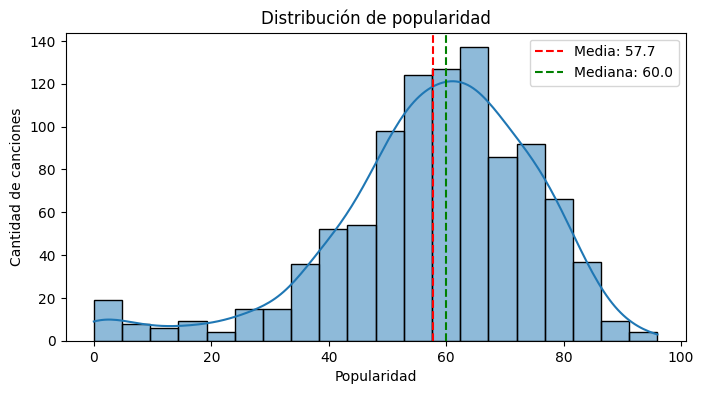

In [69]:
plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="Popularity", bins=20, kde=True)

plt.axvline(df["Popularity"].mean(), color="red", linestyle="--", label=f"Media: {df['Popularity'].mean():.1f}")
plt.axvline(df["Popularity"].median(), color="green", linestyle="--", label=f"Mediana: {df['Popularity'].median():.1f}")

plt.title("Distribución de popularidad")
plt.xlabel("Popularidad")
plt.ylabel("Cantidad de canciones")
plt.legend()
plt.show()


In [70]:
import numpy as np
from scipy.stats import skew, kurtosis, entropy


In [71]:
variable_numerica = "Popularity"

serie = df[variable_numerica].dropna()

resumen_numerico = {
    "asimetria_skewness": skew(serie),
    "curtosis_exceso": kurtosis(serie)
}

resumen_numerico


{'asimetria_skewness': np.float64(-0.9757211729078444),
 'curtosis_exceso': np.float64(1.4205094900913995)}

En *Popularity*,la asimetría es negativa (-0.98), por lo que la distribución tiene cola hacia valores bajo, como se ve en el historgrama.
La curtosis exceso es positiva (1.42),coincidiendo con tener una cola mas pesada que la distribucion normal. --> **Pregunta**: Cuando no tenes el histograma para verlo, como sabes cuanto es una asimetría alta y una curtois en exceso alta?


## 5. Grafico 2: duracion de las canciones

Uso un boxplot para resumir la distribucion de la duracion e identificar valores extremos fuera de los bigotes.


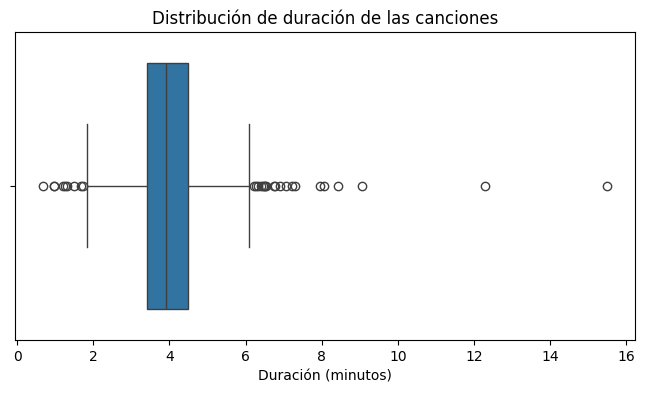

In [72]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Duration_minutes")

plt.title("Distribución de duración de las canciones")
plt.xlabel("Duración (minutos)")
plt.show()


## 6. Relacion entre variables

Para responder la relacion entre variables miro los mapas de calor de las correlaciones de Pearson, Spearman y Kendall. No es suficiente tener solo una para asegurar correlacion ya que Pearson solo habla de correlacion lineal por ejemplo. Primero defino las variables numéricas que tiene sentido correlacionar y luego hago los gráficos


In [73]:
variables_correlacion = [
    "Popularity",
    "Duration_minutes",
    "Danceability",
    "Energy",
    "Loudness",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo"
]


In [74]:
corr_pearson = df[variables_correlacion].corr(method="pearson")
corr_spearman = df[variables_correlacion].corr(method="spearman")
corr_kendall = df[variables_correlacion].corr(method="kendall")

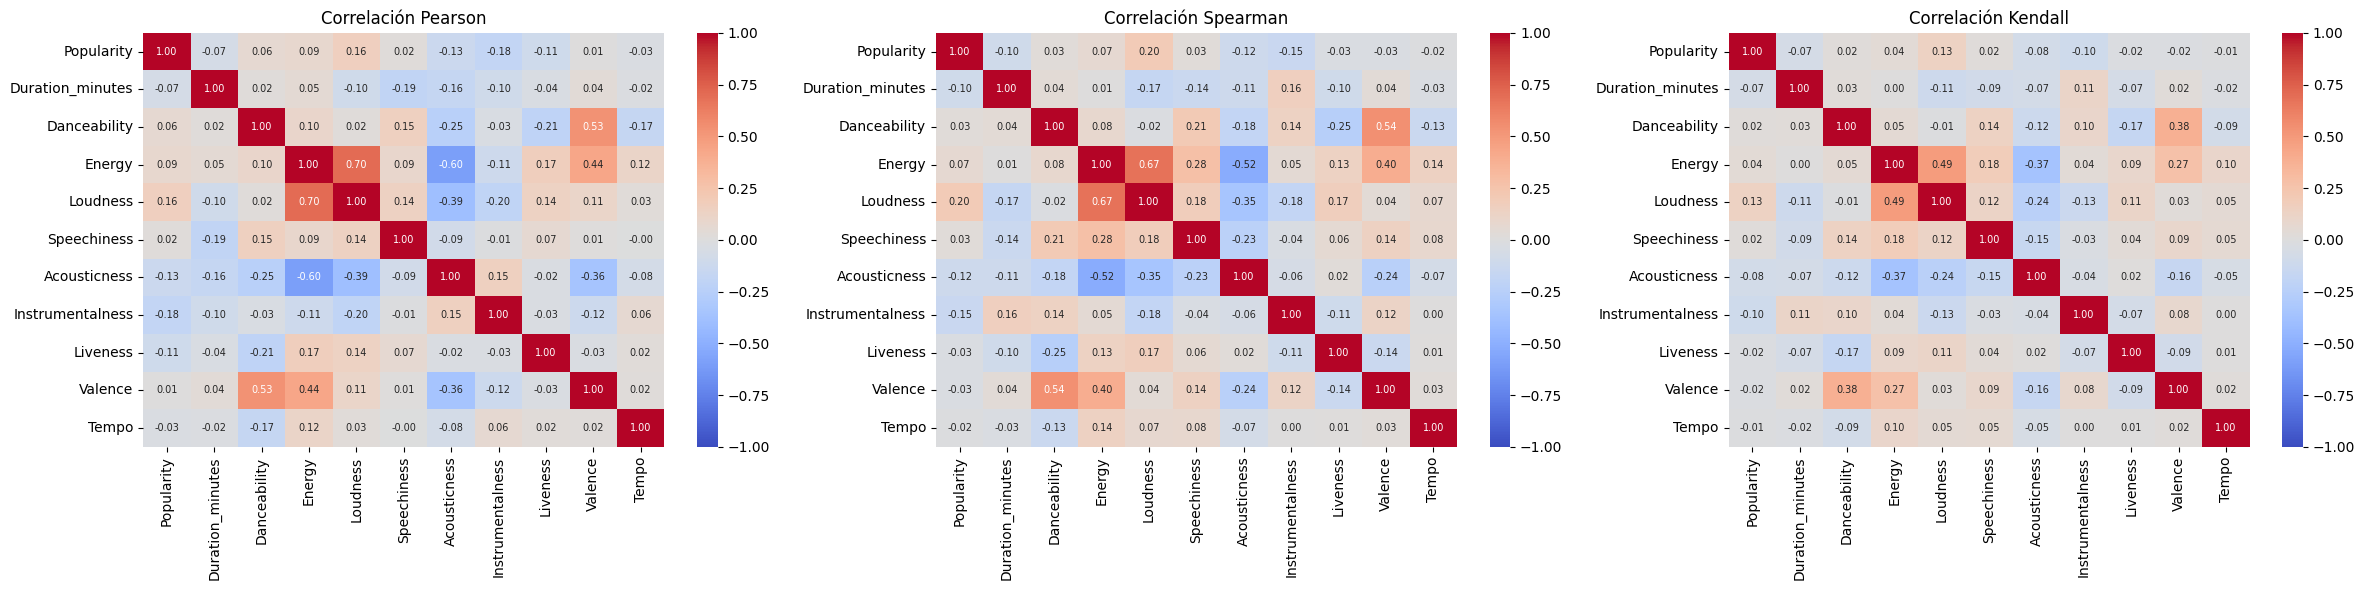

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.heatmap(
    corr_pearson,
    ax=axes[0],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)
axes[0].set_title("Correlación Pearson")

sns.heatmap(
    corr_spearman,
    ax=axes[1],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)
axes[1].set_title("Correlación Spearman")

sns.heatmap(
    corr_kendall,
    ax=axes[2],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7}
)
axes[2].set_title("Correlación Kendall")

plt.tight_layout()
plt.show()


**Lectura de relaciones numericas**

En los tres métodos veo una relación positiva entre *Energy* y Loudness. Esto tiene todo el sentido, ya que las canciones con mayor energía tienden a tener mayor volumen. También aparece una relación negativa entre Acousticness y Energy, de nuevo con mucho sentido.

El resto de las correlaciones son más débiles, esperaba mayor correlacion entre Danceability y Valence por ejemplo. Igualmente, me cuesta darme cuenta con el número en la matriz, así que hago un gráfico de dispersion de las que mostraron mayor relacion en los mapas de calor.



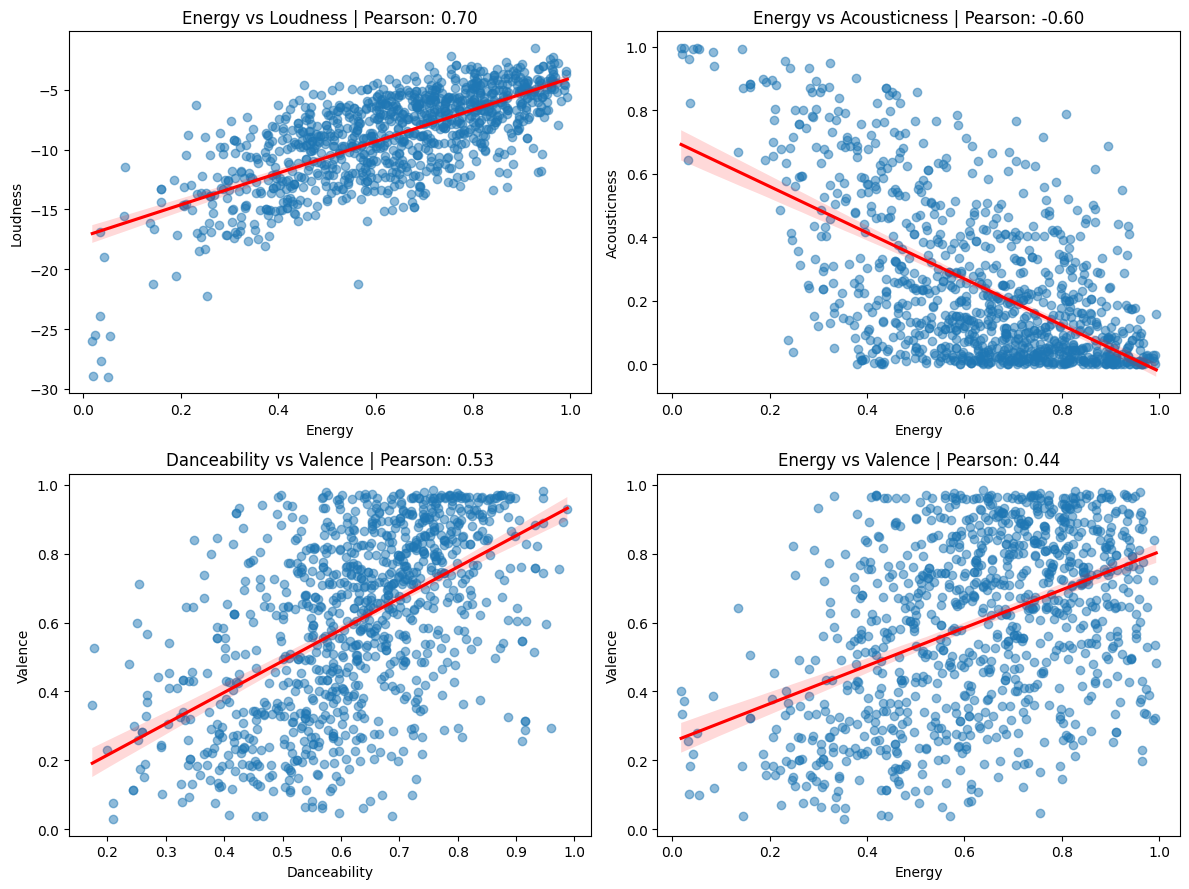

In [76]:
pares_correlacion = [
    ("Energy", "Loudness"),
    ("Energy", "Acousticness"),
    ("Danceability", "Valence"),
    ("Energy", "Valence")
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, (x, y) in enumerate(pares_correlacion):
    sns.regplot(
        data=df,
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )
    
    correlacion = df[[x, y]].corr(method="pearson").iloc[0, 1]
    axes[i].set_title(f"{x} vs {y} | Pearson: {correlacion:.2f}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)

plt.tight_layout()
plt.show()


La verdad que no veo una relacion lineal clara, solo en energy y Loudness coincidiendo con el mayor valor de Pearson. --> **Pregunta**: Como defino valores para ver relaciones? Porque 0,6 tambien me parecía bastante fuerte y sin embargo gráficamente no lo veo.

##  Analisis de las variables categóricas
Para no quedarme solo con las numéricas que me resultan más intuitivas de analizar, reviso las variables categóricas también


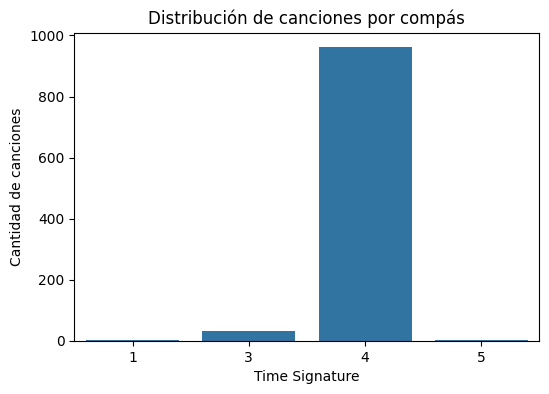

In [77]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Time_Signature")
plt.title("Distribución de canciones por compás")
plt.xlabel("Time Signature")
plt.ylabel("Cantidad de canciones")
plt.show()


### Popularidad segun el modo (mayor o menor)

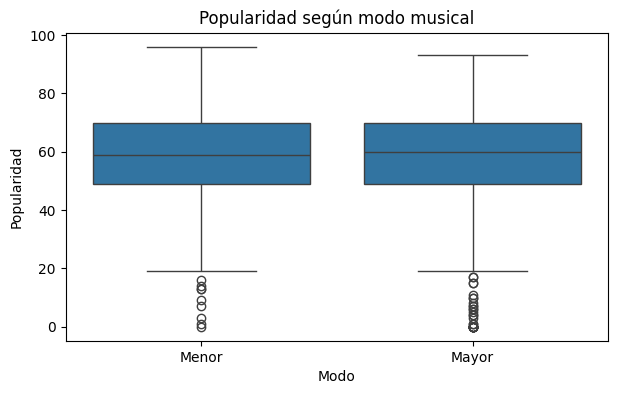

In [78]:
mode_map = {
    0: "Menor",
    1: "Mayor"
}

df["Mode_name"] = df["Mode"].astype(int).map(mode_map)

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Mode_name",
    y="Popularity"
)

plt.title("Popularidad según modo musical")
plt.xlabel("Modo")
plt.ylabel("Popularidad")
plt.show()


No veo diferencias. Las medias son muy similares, al igual que los outliers.

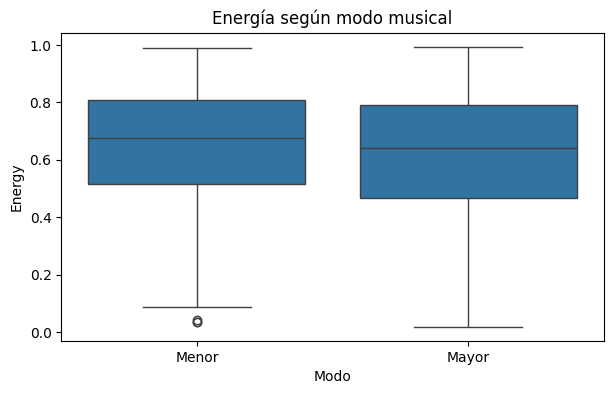

In [79]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df,
    x="Mode_name",
    y="Energy"
)

plt.title("Energía según modo musical")
plt.xlabel("Modo")
plt.ylabel("Energy")
plt.show()



Las distribuciones de Energy para modo menor y mayor son bastante similares. Aunque el modo menor tiene una mediana ligeramente más alta, no puedo decirque el modo está relacionado con la energia de las canciones


## Conclusion
 
En este EDA básico analicé el dataset de canciones clásicas de los 80 aplicando herramientas vistas en clase. Tomé como base el análisis del titanic para seguir un análisis ordenado.

Primero revisé la estructura del dataset, los valores faltantes y la estadística descriptiva de las variables principales.

Luego, identifiqué los tipos de variables y mire que por default Pandas trataba algunas categoricas como numericas o duracion (numerica) como objeto (texto) e hice los cambios correspondientes.

Por último revisé las relaciones entre variables e hice algunos gráficos para poder observarlas mejor.

Como resumen general, el dataset no presenta valores faltantes importantes y tiene canciones mayormente bailables, energéticas y en compas 4x4. 

